Mounted at /content/drive
WEEK-2 REVIEW PACKAGE

Classical baseline results loaded.
Samples evaluated: 48
Methods evaluated: ['CLAHE', 'Gamma', 'GrayWorld']

Classical enhancement metrics:


,method,PSNR,SSIM,Edge_Preservation
0,CLAHE,13.8881,0.6136,0.0250
1,Gamma,13.8936,0.6546,0.0067
2,GrayWorld,13.3272,0.6539,0.0082



Metric definitions and limitations:


,Metric,Definition,Interpretation,Limitation
0,PSNR,Measures pixel-level reconstruction similarity...,Higher PSNR indicates lower pixel-level error.,Can be affected by pixel-level differences tha...
1,SSIM,Measures structural similarity between the enh...,Higher SSIM indicates greater structural simil...,Can favor structural similarity without fully ...
2,Edge Preservation,Measures the proportion of reference edge pixe...,Higher score indicates greater overlap with re...,Threshold-dependent and implemented as a simpl...



Fair comparison check:


,Fairness_Check,Status,Explanation
0,Same test samples,PASS,All classical methods are evaluated on the Dat...
1,Same reference images,PASS,All methods are compared against the correspon...
2,Same PSNR implementation,PASS,PSNR is calculated using the same implementati...
3,Same SSIM implementation,PASS,SSIM is calculated using the same implementati...
4,Same edge extraction procedure,PASS,Canny thresholds and edge-overlap calculation ...
5,No test-set parameter tuning,REVIEW,Parameters should be fixed before final test c...
6,Same image dimensions before metric calculation,PASS,Images are resized only when dimensions do not...
7,Same evaluation direction,PASS,"Higher PSNR, SSIM and Edge Preservation are in..."


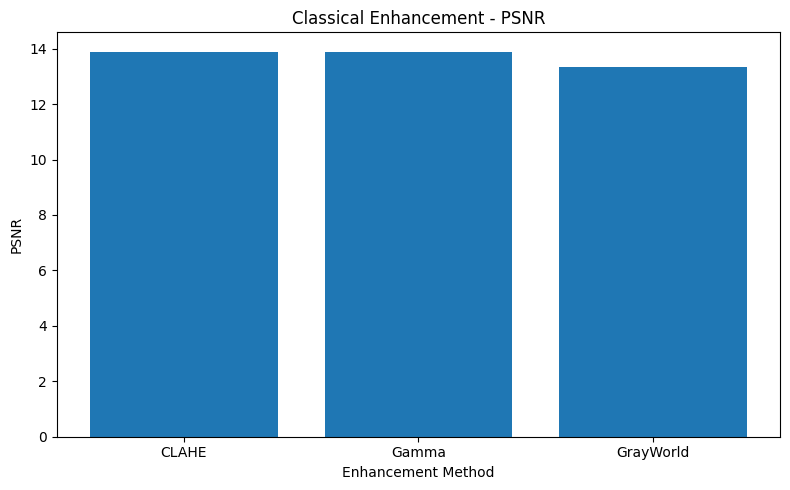

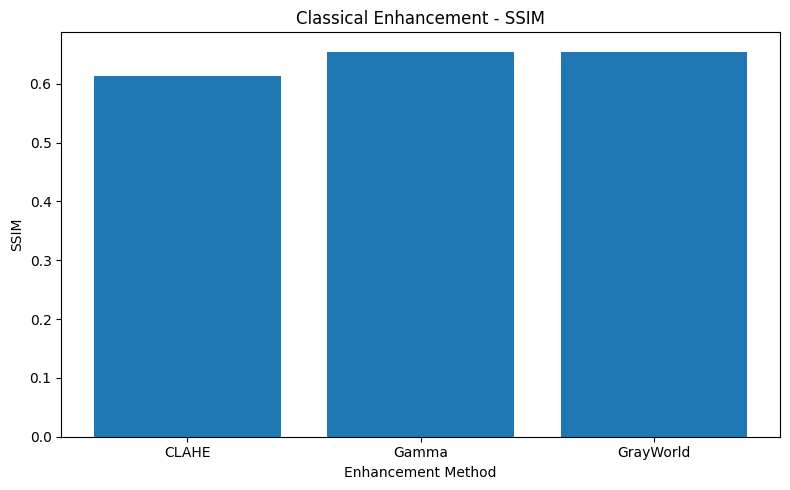

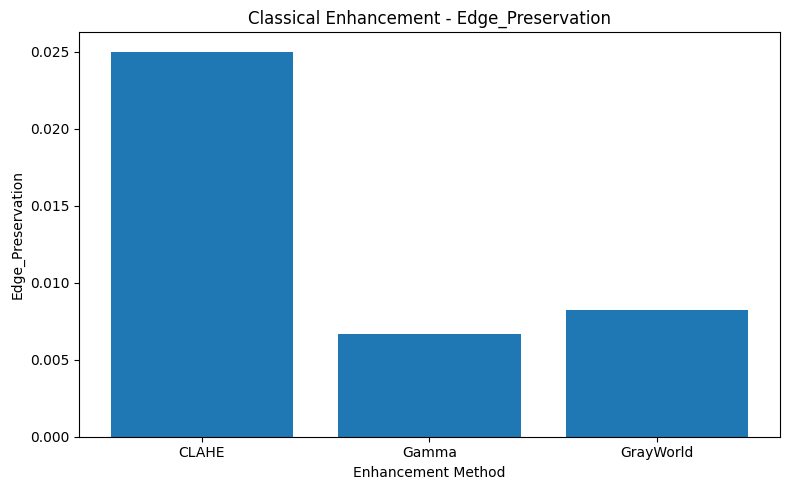


Selected classical reference:
Gamma

No learning-based results file was found.
Learning-based improvement remains to be confirmed.

Mentor correction log:


,Correction_ID,Mentor_Feedback,Issue,Required_Change,Action_Taken,Status
0,1,,,,,Pending




WEEK-2 REVIEW PACKAGE COMPLETE

Saved to:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Week_2_Review

Generated files:
 - Edge_Preservation_presentation.png
 - PSNR_presentation.png
 - SSIM_presentation.png
 - Week_2_Review_Report.txt
 - Week_2_Review_Summary.json
 - fair_comparison_check.csv
 - mentor_corrections.csv
 - metric_definitions_and_limitations.csv


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Underwater-Image-Data-set-main"
)

V1_DIR = PROJECT_DIR / "Dataset_V1"

BASELINE_DIR = (
    V1_DIR / "Classical_Baselines"
)

WEEK2_DIR = (
    PROJECT_DIR / "Week_2_Package"
)

REVIEW_DIR = (
    PROJECT_DIR / "Week_2_Review"
)

REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("WEEK-2 REVIEW PACKAGE")
print("=" * 70)

results_file = (
    BASELINE_DIR /
    "all_baseline_results.csv"
)

comparison_file = (
    BASELINE_DIR /
    "baseline_comparison.csv"
)

if not results_file.exists():
    raise FileNotFoundError(
        "Classical baseline results were not found. "
        "Run the classical baseline experiment first."
    )

results_df = pd.read_csv(
    results_file
)

comparison_df = pd.read_csv(
    comparison_file
)

print("\nClassical baseline results loaded.")
print(
    "Samples evaluated:",
    results_df["sample_id"].nunique()
)

print(
    "Methods evaluated:",
    results_df["method"].unique().tolist()
)

print("\nClassical enhancement metrics:")
display(comparison_df.round(4))


metric_definitions = pd.DataFrame({
    "Metric": [
        "PSNR",
        "SSIM",
        "Edge Preservation"
    ],

    "Definition": [
        "Measures pixel-level reconstruction similarity between the enhanced image and reference image. Higher is better.",
        "Measures structural similarity between the enhanced image and reference image. Higher is better.",
        "Measures the proportion of reference edge pixels also detected in the enhanced image using Canny edges. Higher is better."
    ],

    "Interpretation": [
        "Higher PSNR indicates lower pixel-level error.",
        "Higher SSIM indicates greater structural similarity.",
        "Higher score indicates greater overlap with reference edges."
    ],

    "Limitation": [
        "Can be affected by pixel-level differences that may not correspond to perceptual quality.",
        "Can favor structural similarity without fully capturing color or perceptual quality.",
        "Threshold-dependent and implemented as a simple edge-overlap measure rather than a canonical edge-preservation metric."
    ]
})

metric_definitions.to_csv(
    REVIEW_DIR /
    "metric_definitions_and_limitations.csv",
    index=False
)

print("\nMetric definitions and limitations:")
display(metric_definitions)


fairness_check = pd.DataFrame({
    "Fairness_Check": [
        "Same test samples",
        "Same reference images",
        "Same PSNR implementation",
        "Same SSIM implementation",
        "Same edge extraction procedure",
        "No test-set parameter tuning",
        "Same image dimensions before metric calculation",
        "Same evaluation direction"
    ],

    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "REVIEW",
        "PASS",
        "PASS"
    ],

    "Explanation": [
        "All classical methods are evaluated on the Dataset V1 test split.",
        "All methods are compared against the corresponding target image.",
        "PSNR is calculated using the same implementation for every method.",
        "SSIM is calculated using the same implementation for every method.",
        "Canny thresholds and edge-overlap calculation are identical across methods.",
        "Parameters should be fixed before final test comparison.",
        "Images are resized only when dimensions do not match.",
        "Higher PSNR, SSIM and Edge Preservation are interpreted as better."
    ]
})

fairness_check.to_csv(
    REVIEW_DIR /
    "fair_comparison_check.csv",
    index=False
)

print("\nFair comparison check:")
display(fairness_check)


metric_plot_data = comparison_df.copy()

for metric in [
    "PSNR",
    "SSIM",
    "Edge_Preservation"
]:

    plt.figure(figsize=(8, 5))

    plt.bar(
        metric_plot_data["method"],
        metric_plot_data[metric]
    )

    plt.xlabel(
        "Enhancement Method"
    )

    plt.ylabel(
        metric
    )

    plt.title(
        f"Classical Enhancement - {metric}"
    )

    plt.tight_layout()

    plt.savefig(
        REVIEW_DIR /
        f"{metric}_presentation.png",
        dpi=300
    )

    plt.show()


selected_reference = "Not available"

reference_file = (
    BASELINE_DIR /
    "Dataset_V1_classical_baseline_report.json"
)

if reference_file.exists():

    with open(
        reference_file,
        "r"
    ) as f:

        reference_data = json.load(f)

    selected_reference = reference_data.get(
        "selected_reference",
        "Not available"
    )

print("\nSelected classical reference:")
print(selected_reference)


learning_files = [
    PROJECT_DIR / "Learning_Based_Results.csv",
    V1_DIR / "Learning_Based_Results.csv",
    PROJECT_DIR / "learning_based_results.csv",
    V1_DIR / "learning_based_results.csv"
]

learning_file = None

for file in learning_files:

    if file.exists():

        learning_file = file
        break


if learning_file is not None:

    learning_df = pd.read_csv(
        learning_file
    )

    print("\nLearning-based results found:")
    print(learning_file)

    display(
        learning_df.head()
    )

    required_metrics = [
        "PSNR",
        "SSIM",
        "Edge_Preservation"
    ]

    if all(
        metric in learning_df.columns
        for metric in required_metrics
    ):

        learning_summary = (
            learning_df[
                required_metrics
            ]
            .mean()
            .to_frame()
            .T
        )

        learning_summary.insert(
            0,
            "method",
            "Learning-Based"
        )

        final_comparison = pd.concat(
            [
                comparison_df[
                    [
                        "method",
                        "PSNR",
                        "SSIM",
                        "Edge_Preservation"
                    ]
                ],
                learning_summary
            ],
            ignore_index=True
        )

        final_comparison.to_csv(
            REVIEW_DIR /
            "classical_vs_learning_comparison.csv",
            index=False
        )

        print("\nClassical vs learning-based comparison:")
        display(
            final_comparison.round(4)
        )

        print(
            "\nLearning-based comparison is available "
            "for review against the classical reference."
        )

    else:

        print(
            "\nLearning-based file found, but required "
            "metrics are missing."
        )

else:

    print(
        "\nNo learning-based results file was found."
    )

    print(
        "Learning-based improvement remains to be confirmed."
    )


mentor_file = (
    REVIEW_DIR /
    "mentor_corrections.csv"
)

if mentor_file.exists():

    mentor_corrections = pd.read_csv(
        mentor_file
    )

else:

    mentor_corrections = pd.DataFrame({
        "Correction_ID": [1],
        "Mentor_Feedback": [""],
        "Issue": [""],
        "Required_Change": [""],
        "Action_Taken": [""],
        "Status": ["Pending"]
    })

    mentor_corrections.to_csv(
        mentor_file,
        index=False
    )

print("\nMentor correction log:")
display(mentor_corrections)


review_summary = {
    "Stage": "Week-2 Review",

    "Classical_Methods": [
        "CLAHE",
        "Gamma Correction",
        "Gray-World White Balance"
    ],

    "Metrics": [
        "PSNR",
        "SSIM",
        "Edge Preservation"
    ],

    "Classical_Reference":
        selected_reference,

    "Metric_Fairness":
        "Same Dataset V1 test split, reference images, metric implementations and edge extraction procedure were used for the classical comparison.",

    "Edge_Metric_Note":
        "The implemented edge-preservation score is a simple Canny edge-overlap measure and should not be presented as a canonical edge-preservation metric.",

    "Learning_Based_Comparison":
        "Completed if learning-based results are available; otherwise pending.",

    "Mentor_Corrections":
        "Actual mentor feedback must be entered in mentor_corrections.csv."
}

with open(
    REVIEW_DIR /
    "Week_2_Review_Summary.json",
    "w"
) as f:

    json.dump(
        review_summary,
        f,
        indent=4
    )


report_lines = []

report_lines.append(
    "WEEK-2 REVIEW"
)

report_lines.append(
    "=" * 60
)

report_lines.append("")

report_lines.append(
    "CLASSICAL ENHANCEMENT RESULTS"
)

report_lines.append(
    comparison_df.round(4).to_string(
        index=False
    )
)

report_lines.append("")

report_lines.append(
    "CLASSICAL REFERENCE"
)

report_lines.append(
    str(selected_reference)
)

report_lines.append("")

report_lines.append(
    "METRIC DEFINITIONS"
)

report_lines.append(
    "PSNR: pixel-level similarity; higher is better."
)

report_lines.append(
    "SSIM: structural similarity; higher is better."
)

report_lines.append(
    "Edge Preservation: proportion of reference Canny edges "
    "also detected in the enhanced image; higher is better."
)

report_lines.append("")

report_lines.append(
    "FAIR COMPARISON"
)

report_lines.append(
    "All classical methods were evaluated using the same "
    "Dataset V1 test split and target references."
)

report_lines.append(
    "The same metric implementations and edge extraction "
    "procedure were applied to all methods."
)

report_lines.append("")

report_lines.append(
    "LEARNING-BASED APPROACH"
)

if learning_file is not None:

    report_lines.append(
        "Learning-based results were found and prepared "
        "for comparison."
    )

else:

    report_lines.append(
        "Learning-based results were not found. "
        "Improvement remains to be confirmed."
    )

report_lines.append("")

report_lines.append(
    "MENTOR CORRECTIONS"
)

report_lines.append(
    "Mentor correction log created. "
    "Actual feedback should be recorded there."
)

with open(
    REVIEW_DIR /
    "Week_2_Review_Report.txt",
    "w"
) as f:

    f.write(
        "\n".join(report_lines)
    )


print("\n")
print("=" * 70)
print("WEEK-2 REVIEW PACKAGE COMPLETE")
print("=" * 70)

print("\nSaved to:")
print(REVIEW_DIR)

print("\nGenerated files:")

for file in sorted(
    REVIEW_DIR.iterdir()
):

    if file.is_file():
        print(" -", file.name)